Mean JSD over 1598 sequences: 0.147060


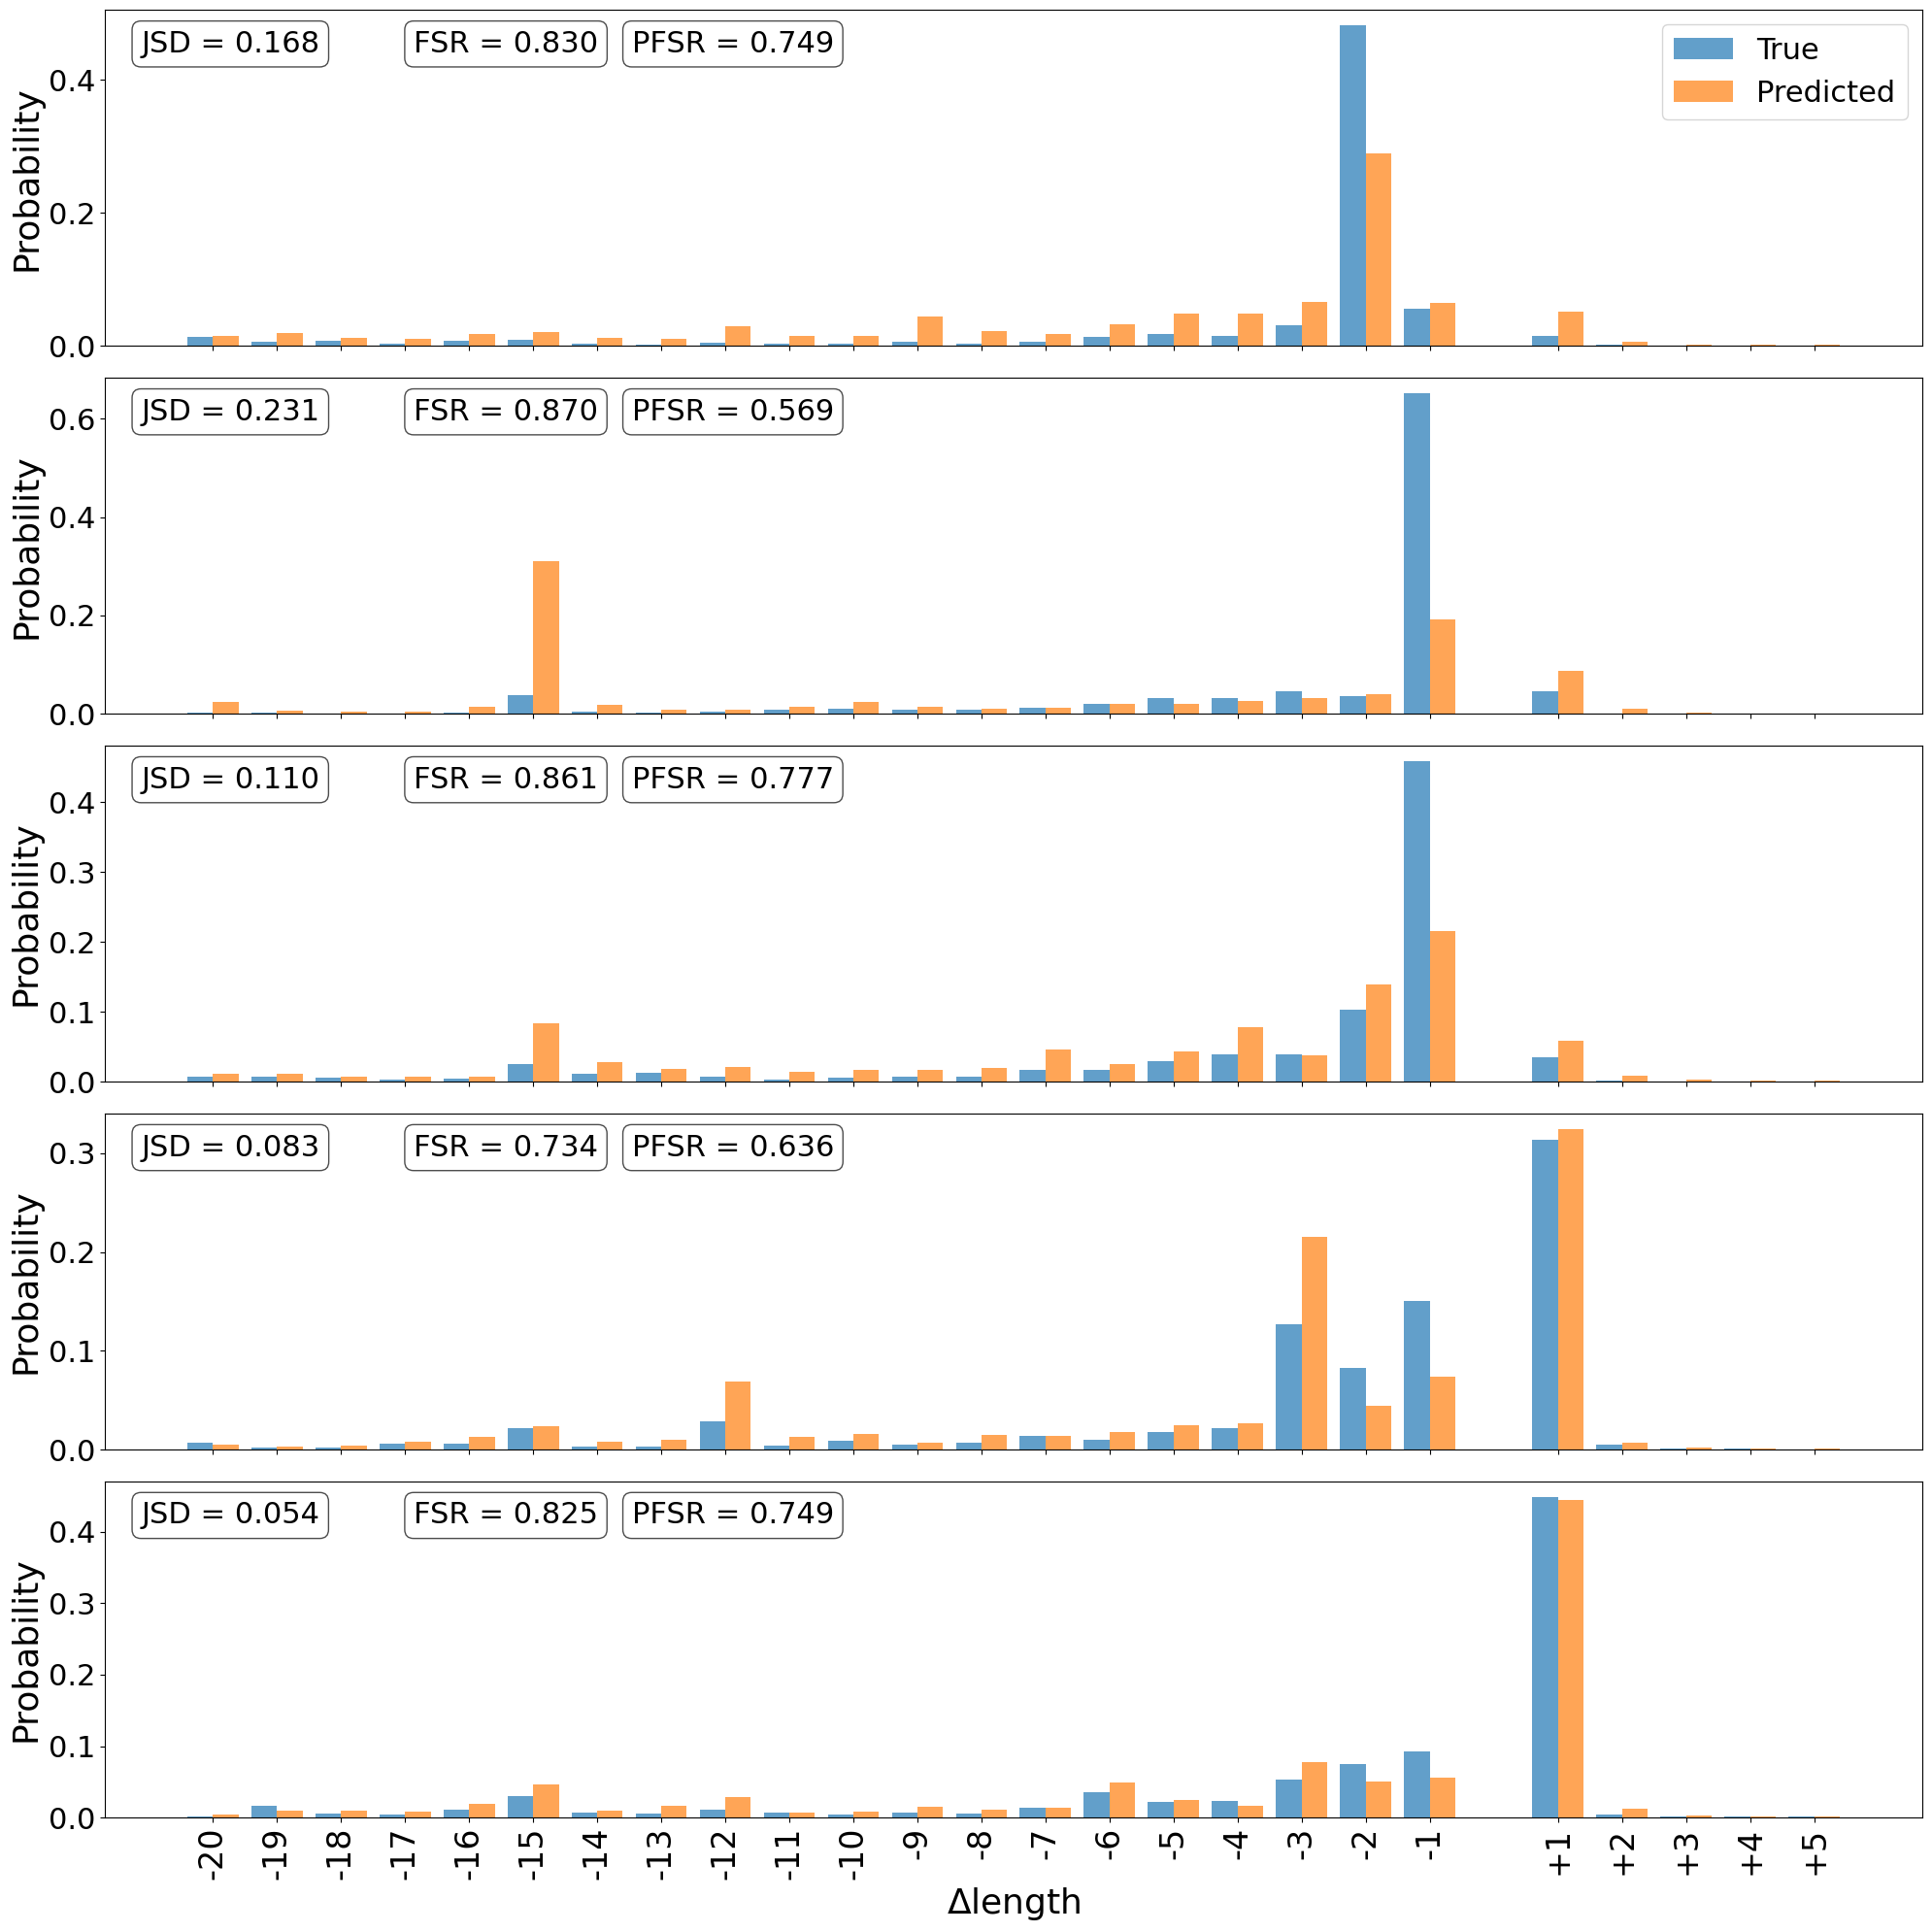

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the FORECasT K562 outcomes table
csv_path = "ADL/FORECasT_K562_outcomes.csv"
df = pd.read_csv(csv_path)

# Use overlapping positions that have both true counts and predicted (delta_) columns
positions = list(range(-70, 21))
orig_cols = [str(p) for p in positions if str(p) in df.columns]
delta_cols = [f"delta_{p}" for p in positions if f"delta_{p}" in df.columns]

# Make sure we are comparing the same support for true and predicted
if len(orig_cols) == 0 or len(orig_cols) != len(delta_cols):
    raise ValueError("Could not align true and predicted delta-length columns.")

pos_array = np.array([int(c) for c in orig_cols])

# Positions to display in plots
plot_mask = (pos_array >= -20) & (pos_array <= 5)
plot_positions = pos_array[plot_mask]

# Nicely formatted labels (e.g. +5 instead of 5)
plot_labels = [
    ("+" + str(p) if p > 0 else str(p))
    for p in plot_positions
]


def js_divergence(p: np.ndarray, q: np.ndarray) -> float:
    """Jensen-Shannon divergence between two discrete distributions.

    Both p and q are normalized internally to sum to 1.
    Uses log base 2 so JSD is in [0, 1].
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    psum = p.sum()
    qsum = q.sum()
    if psum <= 0 or qsum <= 0:
        return np.nan

    p = p / psum
    q = q / qsum
    m = 0.5 * (p + q)

    # KL(p || m)
    mask_p = (p > 0) & (m > 0)
    kl_pm = np.sum(p[mask_p] * np.log2(p[mask_p] / m[mask_p]))

    # KL(q || m)
    mask_q = (q > 0) & (m > 0)
    kl_qm = np.sum(q[mask_q] * np.log2(q[mask_q] / m[mask_q]))

    return 0.5 * (kl_pm + kl_qm)


def row_jsd(row: pd.Series) -> float:
    true_vals = row[orig_cols].to_numpy(dtype=float)
    pred_vals = row[delta_cols].to_numpy(dtype=float)
    return js_divergence(true_vals, pred_vals)


# Compute per-sequence read count from true (pre-normalization) deltas
# and JSD per sequence, then mean JSD
df["read_count"] = df[orig_cols].sum(axis=1)
df["JSD"] = df.apply(row_jsd, axis=1)
valid_jsd = df["JSD"].dropna()
mean_jsd = valid_jsd.mean()

print(f"Mean JSD over {len(valid_jsd)} sequences: {mean_jsd:.6f}")

# Plot true vs predicted distributions for a few example sequences
num_examples = 5  # top X sequences by read count
examples = (
    df[df["JSD"].notna()]
    .sort_values("read_count", ascending=False)
    .head(num_examples)
)

fig, axes = plt.subplots(num_examples, 1, figsize=(20, 4 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]

# Configure x-axis ticks for clear delta-length display (cropped range)
for ax in axes:
    ax.set_xticks(plot_positions)
    ax.set_xticklabels(plot_labels, rotation=90, fontsize=24)
    ax.tick_params(axis="y", labelsize=22)

for ax, (idx, row) in zip(axes, examples.iterrows()):
    true_vals = row[orig_cols].to_numpy(dtype=float)
    pred_vals = row[delta_cols].to_numpy(dtype=float)

    # Normalize each distribution to sum to 1 (again, explicitly for clarity)
    if true_vals.sum() > 0:
        true_vals = true_vals / true_vals.sum()
    if pred_vals.sum() > 0:
        pred_vals = pred_vals / pred_vals.sum()

    # Crop to the plotting window [-20, +5]
    plot_true = true_vals[plot_mask]
    plot_pred = pred_vals[plot_mask]

    # Frameshift rates (sum of probabilities where delta length not divisible by 3)
    fs_mask = (pos_array % 3) != 0
    fsr = float(true_vals[fs_mask].sum()) if true_vals.sum() > 0 else np.nan
    pfsr = float(pred_vals[fs_mask].sum()) if pred_vals.sum() > 0 else np.nan

    ax.bar(plot_positions - 0.2, plot_true, width=0.4, label="True", alpha=0.7)
    ax.bar(plot_positions + 0.2, plot_pred, width=0.4, label="Predicted", alpha=0.7)

    # Add JSD, FSR, and PFSR inside the plot (single top row, closer together)
    ax.text(0.02, 0.94, f"JSD = {row['JSD']:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.text(0.17, 0.94, f"FSR = {fsr:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.text(0.29, 0.94, f"PFSR = {pfsr:.3f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # No per-sequence title; keep only large axes/labels
    ax.set_ylabel("Probability", fontsize=26)

axes[-1].set_xlabel("$\Delta$length", fontsize=26)
axes[0].legend(fontsize=22)
plt.tight_layout()
plt.savefig("delta_length_distributions.pdf")
plt.show()


In [2]:
# Baseline JSD: true distribution vs uniform over same support
n_pos = len(orig_cols)
uniform = np.ones(n_pos) / n_pos

def row_jsd_vs_uniform(row):
    true_vals = row[orig_cols].to_numpy(dtype=float)
    if true_vals.sum() <= 0:
        return np.nan
    true_vals = true_vals / true_vals.sum()
    return js_divergence(true_vals, uniform)

df["JSD_baseline"] = df.apply(row_jsd_vs_uniform, axis=1)
valid_baseline = df["JSD_baseline"].dropna()
mean_jsd_baseline = valid_baseline.mean()
std_jsd = valid_jsd.std()
std_baseline = valid_baseline.std()

print(f"Mean JSD (model):     {mean_jsd:.6f}  std = {std_jsd:.6f}")
print(f"Mean JSD (baseline): {mean_jsd_baseline:.6f}  std = {std_baseline:.6f}")
print(f"Improvement vs uniform: {mean_jsd_baseline - mean_jsd:.6f}")

Mean JSD (model):     0.147060  std = 0.097990
Mean JSD (baseline): 0.476897  std = 0.105607
Improvement vs uniform: 0.329837
